In [1]:
import torch
import torch.nn.functional as F

batch_size = 10
seq_len = 1000
max_id = 10
id_embed_dim = 16
num_heads = 1

In [2]:
X_train = torch.randint(0, max_id, (batch_size, seq_len), dtype=torch.int64)
X_train.shape

torch.Size([10, 1000])

# Retrieval

In [3]:
from torch.nn import MultiheadAttention, Linear
from tqdm import tqdm
import numpy as np
import matplotlib.pyplot as plt



class MyModel(torch.nn.Module):
    def __init__(self, embed_dim, num_heads):
        super(MyModel, self).__init__()
        self.embed_dim = embed_dim * num_heads
        self.num_heads = num_heads
        self.embedding = torch.nn.Embedding(max_id, embed_dim)
        self.attn = MultiheadAttention(embed_dim=self.embed_dim, num_heads=num_heads, batch_first=True)

    def forward(self, x, start: int, end: int):
        x = self.embedding(x)
        x = x.repeat(1, 1, self.num_heads)
        target_len = end - start
        attn_mask = torch.triu(torch.ones(target_len, x.shape[1]), diagonal=start+1).bool()
        return self.attn(x[:, start:end, :], x, x, attn_mask=attn_mask)

        
model = MyModel(embed_dim=id_embed_dim, num_heads=num_heads)


def get_retrieval_target(x, start, end):
    # print(f"x.shape: {x.shape}")
    seq_len = x.shape[1]
    target_indices = torch.arange(start, end).unsqueeze(1)
    source_indices = torch.arange(0, seq_len).unsqueeze(0)
    cond1 = (target_indices > source_indices - start).unsqueeze(0).repeat(x.shape[0], 1, 1)
    a_target = x[:, target_indices]
    a_source = x[:, source_indices]
    cond2 = (a_target == a_source)
    ans = (cond1 & cond2).long()
    return ans


def get_score_and_target(x, start, end):
    """
    This score is the attention weight. The sum must be 1.
    """
    target_len = end - start
    target = get_retrieval_target(x, start, end)
    # print(f"target shape: {target.shape}")
    attn_mask = ~torch.triu(torch.ones(target_len, x.shape[1]), diagonal=start+1).bool()
    target = target[:, attn_mask]
    # print(target.shape)  # [batch_size, 55]
    attn_score = model(x, start, end)[1]
    # print(f"attn_mask shape: {attn_mask.shape}")
    x = attn_score[:, attn_mask]
    # attn_score[:, ~attn_mask] is always 0 
    # print(x.shape) == [batch_size, 55]  (55 is the num of non-masked elements)
    # loss = criterion(x, target.float())
    return x, target


class ExponentialMovingAverage:
    def __init__(self, alpha=0.01):
        self.alpha = alpha
        self.moving_avg = None
        self.history = []
    
    def update(self, value):
        if self.moving_avg is None:
            self.moving_avg = value
        else:
            self.moving_avg = self.alpha * value + (1 - self.alpha) * self.moving_avg
        self.history.append(self.moving_avg)
    
    def get_average(self):
        return self.moving_avg


def evaluation(x0):
    cnt_0 = 0
    cnt_1 = 0
    acc_0 = 0.0
    acc_1 = 0.0
    with torch.no_grad():
        for start in range(0, seq_len, 100):
            end = min(start + 100, seq_len)
            avg = 1.0 / seq_len
            score, target = get_score_and_target(x0, start, end)
            # We set the threshold to be random guess (1 / seq_len)
            x = (score > avg).long().view(-1)
            y = target.long().view(-1)
            acc_0 += ((x == y) & (y == 0)).float().sum().item()
            acc_1 += ((x == y) & (y == 1)).float().sum().item()
            cnt_0 += (y == 0).int().sum().item()
            cnt_1 += (y == 1).int().sum().item()
    print(f'Accuracy of 1: {acc_1 / cnt_1:.4f} ({acc_1}/{cnt_1})')
    print(f'Accuracy of 0: {acc_0 / cnt_0:.4f} ({acc_0}/{cnt_0})')


# get_score_and_target(X_train, 0, 10)

print('Initial evaluation:')
evaluation(X_train)

Initial evaluation:
Accuracy of 1: 0.6880 (349675.0/508267)
Accuracy of 0: 0.2697 (1212871.0/4496733)


100%|██████████| 100/100 [00:21<00:00,  4.71it/s]

Final evaluation:
Accuracy of 1: 1.0000 (508267.0/508267)
Accuracy of 0: 0.9998 (4495733.0/4496733)


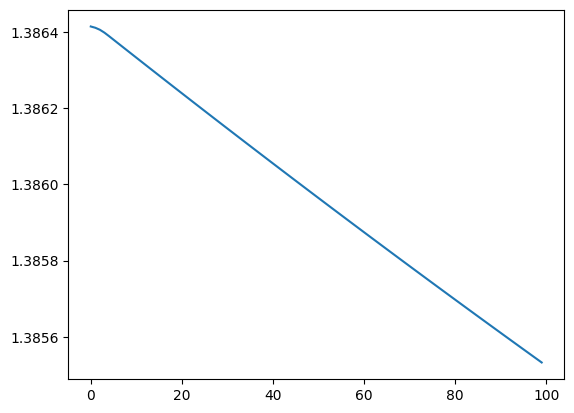

In [4]:

# criterion = torch.nn.BCEWithLogitsLoss(pos_weight=torch.tensor(1000.0))
criterion = torch.nn.BCEWithLogitsLoss()
loss_ema = ExponentialMovingAverage(alpha=0.001)

n_epochs = 100
optimizer = torch.optim.Adam(model.parameters(), lr=0.1)
scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=40, gamma=0.1)

for _ in tqdm(range(n_epochs)):
    start = 0
    while start < seq_len:
        ss = 5000 // (start + 1)
        assert ss > 0
        end = min(start + ss, seq_len)
        score, target = get_score_and_target(X_train, start, end)
        score, target = score.view(-1), target.view(-1)
        # print(score.shape, target.shape)
        a = np.arange(score.shape[0])
        a = np.random.permutation(a)
        score = score[a]
        target = target[a]
        idx_0 = np.arange(score.shape[0])[target == 0]
        idx_1 = np.arange(score.shape[0])[target == 1]
        if len(idx_0) < len(idx_1):
            idx_0 = np.random.choice(idx_0, len(idx_1), replace=True)
        elif len(idx_1) < len(idx_0):
            idx_1 = np.random.choice(idx_1, len(idx_0), replace=True)
        score_0 = score[idx_0]
        score_1 = score[idx_1]
        target_0 = target[idx_0]
        target_1 = target[idx_1]
        # loss = criterion(score_1.float(), target_1.float()) 
        # loss = criterion(score_0.float(), target_0.float())
        loss = criterion(score_0.float(), target_0.float()) + criterion(score_1.float(), target_1.float())
        loss_ema.update(loss.item())
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        start = end
    scheduler.step()

plt.plot(loss_ema.history)
print('Final evaluation:')
evaluation(X_train)

In [5]:
# Test on OOS
test_batch_size = 3
test_seq_len = 1000
X_test = torch.randint(0, max_id, (test_batch_size, test_seq_len), dtype=torch.int64)
print('OOS evaluation:')
evaluation(X_test)

OOS evaluation:
Accuracy of 1: 1.0000 (152661.0/152661)
Accuracy of 0: 0.9998 (1348539.0/1348839)
